# ⚙️ Preprocesado para Clasificación — TED 2018-2023

## 🎯 Objetivo: predecir si el contrato adjudicado va a una PYME (`B_CONTRACTOR_SME`)

| # | Decisión | Justificación |
|---|----------|----|
| 1 | **Filtrar solo España** | De 6.2M filas → ~300–500K. Contexto legal homogéneo. |
| 2 | **Target: B_CONTRACTOR_SME** (Y→1/N→0) | Variable binaria limpia y bien documentada. |
| 3 | **Drop contratos cancelados** | Sin adjudicatario → target nulo. |
| 4 | **Drop identificadores y URLs** | Sin poder predictivo. |
| 5 | **Drop texto libre** | Alta cardinalidad sin NLP. |
| 6 | **Drop geografía granular** | Sustituida por TAL_LOCATION_NUTS. |
| 7 | **Drop valores redundantes** | Variantes derivadas de VALUE_EURO. |
| 8 | **Drop columnas de país** | Constantes tras filtrar ES. |
| 9 | **⚠️ Marcar leakage post-adjudicación** | NUMBER_TENDERS_SME correlaciona directamente con target. |
| 10 | **Imputación** | Numéricas → mediana. Categóricas → 'UNKNOWN'. |
| 11 | **Encoding** | Binarias Y/N → 1/0. Resto → Label Encoding para árboles. |
| 12 | **Drop columnas técnicas/alta nulidad** | XSD_VERSION, GPA_COVERAGE, OUT_OF_DIRECTIVES, etc. |

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn -q


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

BG, AX, TEXT = '#0f1117', '#161b2e', '#dce1f0'
ACC, ACC2, MUTED = '#4cc9f0', '#f72585', '#8892b0'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': AX, 'axes.edgecolor': '#252a40',
    'axes.labelcolor': TEXT, 'axes.titlecolor': TEXT, 'xtick.color': MUTED,
    'ytick.color': MUTED, 'text.color': TEXT, 'grid.color': '#252a40',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 11
})
print('✅ Librerias OK')

✅ Librerias OK


## 1. Carga

In [3]:
CSV_PATH = 'export_CAN_2023_2018.csv'
# En Colab sin Drive → descomenta:
# from google.colab import files; up = files.upload(); CSV_PATH = list(up.keys())[0]

for enc in ['utf-8', 'latin-1', 'cp1252']:
    try:
        df_raw = pd.read_csv(CSV_PATH, low_memory=False, encoding=enc)
        print(f'✅ Cargado ({enc}) — {df_raw.shape[0]:,} filas x {df_raw.shape[1]} cols')
        break
    except UnicodeDecodeError:
        continue

✅ Cargado (utf-8) — 6,198,063 filas x 75 cols


## 2. Decision 1 — Filtrar España

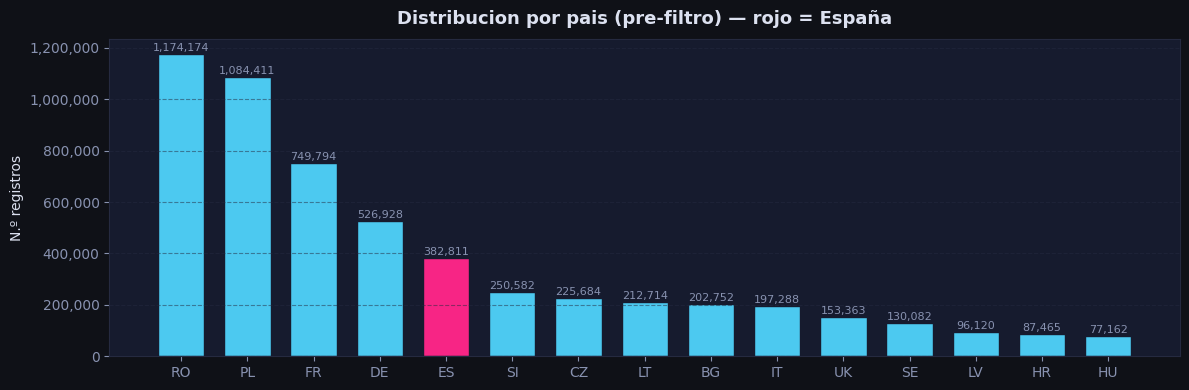


📍 España: 382,811 filas  (6.2% del total)


In [4]:
# Distribucion por pais antes del filtro
top_countries = df_raw['ISO_COUNTRY_CODE'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 4))
colors = [ACC2 if c == 'ES' else ACC for c in top_countries.index]
ax.bar(top_countries.index, top_countries.values, color=colors, edgecolor=AX, width=0.7)
ax.set_title('Distribucion por pais (pre-filtro) — rojo = España')
ax.set_ylabel('N.º registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, axis='y')
for i, (c, v) in enumerate(zip(top_countries.index, top_countries.values)):
    ax.text(i, v + top_countries.max() * 0.01, f'{v:,}', ha='center', fontsize=8, color=MUTED)
plt.tight_layout(); plt.show()

# Filtrar
df = df_raw[df_raw['ISO_COUNTRY_CODE'] == 'ES'].copy()
print(f'\n📍 España: {len(df):,} filas  ({len(df)/len(df_raw)*100:.1f}% del total)')

## 3. Decision 2+3 — Drop cancelados + definir target

In [5]:
print(f'Cancelados: {(df["CANCELLED"]==1).sum():,}  ({(df["CANCELLED"]==1).mean()*100:.1f}%)')
df = df[df['CANCELLED'] != 1].copy()
print(f'Tras eliminar cancelados: {len(df):,} filas')

# Target
print(f'\n🎯 B_CONTRACTOR_SME valores:')
print(df['B_CONTRACTOR_SME'].value_counts(dropna=False))

df['TARGET'] = df['B_CONTRACTOR_SME'].map({'Y': 1, 'N': 0})
n_null_target = df['TARGET'].isna().sum()
print(f'\nNulos en target: {n_null_target:,} → se eliminan')
df = df.dropna(subset=['TARGET']).copy()
df['TARGET'] = df['TARGET'].astype(int)

print(f'\nDataset final pre-feat: {len(df):,} filas')
pyme_pct = df['TARGET'].mean() * 100
print(f'Balance — PYME: {pyme_pct:.1f}%  /  No-PYME: {100-pyme_pct:.1f}%')

Cancelados: 11  (0.0%)
Tras eliminar cancelados: 382,800 filas

🎯 B_CONTRACTOR_SME valores:
B_CONTRACTOR_SME
NaN                                                                                                                                                                                                                                                                  145672
N                                                                                                                                                                                                                                                                    127089
Y                                                                                                                                                                                                                                                                    105576
N---N                                                                                  

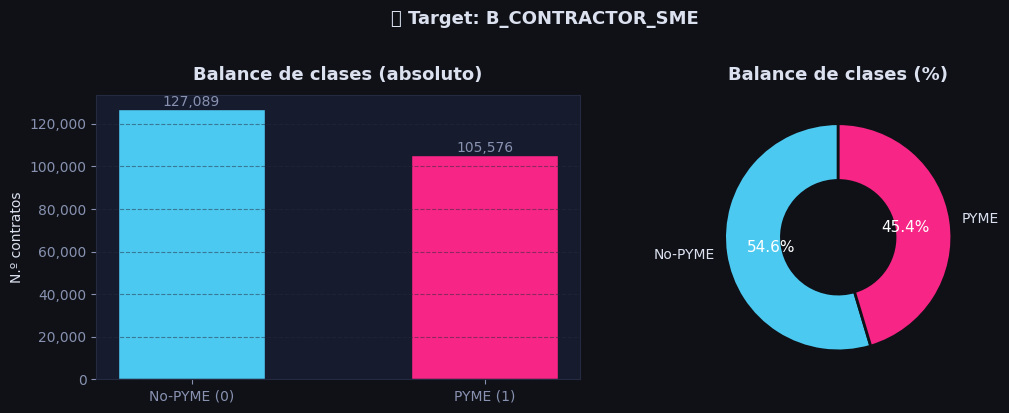

In [6]:
# Balance visual
vc = df['TARGET'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No-PYME (0)', 'PYME (1)'], vc.values, color=[ACC, ACC2], edgecolor=AX, width=0.5)
axes[0].set_title('Balance de clases (absoluto)')
axes[0].set_ylabel('N.º contratos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(True, axis='y')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + vc.max() * 0.01, f'{v:,}', ha='center', fontsize=10, color=MUTED)

pcts = vc / vc.sum() * 100
wedges, texts, autotexts = axes[1].pie(
    pcts.values, labels=['No-PYME', 'PYME'], autopct='%1.1f%%',
    colors=[ACC, ACC2], wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=2), startangle=90)
for at in autotexts:
    at.set_color('white'); at.set_fontsize(11)
axes[1].set_title('Balance de clases (%)')

plt.suptitle('🎯 Target: B_CONTRACTOR_SME', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 4. Decisiones 4–8 y 12 — Eliminar columnas

In [7]:
DROP = {
    'identifiers': [
        'ID_NOTICE_CAN', 'TED_NOTICE_URL', 'ID_LOT', 'ID_LOT_AWARDED',
        'ID_AWARD', 'CONTRACT_NUMBER', 'CAE_NATIONALID', 'WIN_NATIONALID'
    ],
    'free_text': [
        'CAE_NAME', 'CAE_ADDRESS', 'WIN_NAME', 'WIN_ADDRESS',
        'TITLE', 'CRIT_CRITERIA', 'CRIT_WEIGHTS', 'CRIT_PRICE_WEIGHT'
    ],
    'geo_granular': [
        'CAE_TOWN', 'CAE_POSTAL_CODE', 'WIN_TOWN', 'WIN_POSTAL_CODE'
    ],
    'country_redundant': [
        'ISO_COUNTRY_CODE', 'ISO_COUNTRY_CODE_GPA',
        'ISO_COUNTRY_CODE_ALL', 'WIN_COUNTRY_CODE'
    ],
    'value_redundant': [
        'VALUE_EURO_FIN_1', 'VALUE_EURO_FIN_2',
        'AWARD_VALUE_EURO_FIN_1', 'AWARD_EST_VALUE_EURO'
    ],
    'technical_meta': [
        'XSD_VERSION', 'GPA_COVERAGE', 'OUT_OF_DIRECTIVES',
        'FRA_ESTIMATED', 'CAE_GPA_ANNEX', 'MAIN_CPV_CODE_GPA',
        'DT_DISPATCH', 'DT_AWARD',
        'CANCELLED',
        'B_CONTRACTOR_SME',
    ],
    'cpv_extra': ['ADDITIONAL_CPVS'],
}

all_drop = [col for cols in DROP.values() for col in cols]
all_drop = [c for c in all_drop if c in df.columns]

print('Columnas eliminadas por categoria:')
for reason, cols in DROP.items():
    existing = [c for c in cols if c in df.columns]
    print(f'  [{reason}]  {len(existing)} cols: {existing}')

df.drop(columns=all_drop, inplace=True)
print(f'\n✅ Columnas restantes: {df.shape[1]}  (target incluido)')

Columnas eliminadas por categoria:
  [identifiers]  8 cols: ['ID_NOTICE_CAN', 'TED_NOTICE_URL', 'ID_LOT', 'ID_LOT_AWARDED', 'ID_AWARD', 'CONTRACT_NUMBER', 'CAE_NATIONALID', 'WIN_NATIONALID']
  [free_text]  8 cols: ['CAE_NAME', 'CAE_ADDRESS', 'WIN_NAME', 'WIN_ADDRESS', 'TITLE', 'CRIT_CRITERIA', 'CRIT_WEIGHTS', 'CRIT_PRICE_WEIGHT']
  [geo_granular]  4 cols: ['CAE_TOWN', 'CAE_POSTAL_CODE', 'WIN_TOWN', 'WIN_POSTAL_CODE']
  [country_redundant]  4 cols: ['ISO_COUNTRY_CODE', 'ISO_COUNTRY_CODE_GPA', 'ISO_COUNTRY_CODE_ALL', 'WIN_COUNTRY_CODE']
  [value_redundant]  4 cols: ['VALUE_EURO_FIN_1', 'VALUE_EURO_FIN_2', 'AWARD_VALUE_EURO_FIN_1', 'AWARD_EST_VALUE_EURO']
  [technical_meta]  10 cols: ['XSD_VERSION', 'GPA_COVERAGE', 'OUT_OF_DIRECTIVES', 'FRA_ESTIMATED', 'CAE_GPA_ANNEX', 'MAIN_CPV_CODE_GPA', 'DT_DISPATCH', 'DT_AWARD', 'CANCELLED', 'B_CONTRACTOR_SME']
  [cpv_extra]  1 cols: ['ADDITIONAL_CPVS']

✅ Columnas restantes: 37  (target incluido)


## 5. Decision 9 — Aviso leakage post-adjudicacion

In [8]:
LEAKAGE_RISK = [
    'NUMBER_OFFERS',
    'NUMBER_TENDERS_SME',       # ALTO RIESGO: correlaciona directamente con target
    'NUMBER_TENDERS_OTHER_EU',
    'NUMBER_TENDERS_NON_EU',
    'NUMBER_OFFERS_ELECTR',
    'AWARD_VALUE_EURO',
    'B_AWARDED_TO_A_GROUP',
    'B_SUBCONTRACTED',
    'NUMBER_AWARDS',
]
present = [c for c in LEAKAGE_RISK if c in df.columns]
print('⚠️  Columnas con riesgo de leakage (mantenidas, pero documentadas):')
for c in present:
    level = '🔴 ALTO' if c == 'NUMBER_TENDERS_SME' else '🟡 MEDIO'
    print(f'  {level}  {c}')

# Para prediccion real (antes de adjudicar), descomenta:
# df.drop(columns=[c for c in LEAKAGE_RISK if c in df.columns], inplace=True)

⚠️  Columnas con riesgo de leakage (mantenidas, pero documentadas):
  🟡 MEDIO  NUMBER_OFFERS
  🔴 ALTO  NUMBER_TENDERS_SME
  🟡 MEDIO  NUMBER_TENDERS_OTHER_EU
  🟡 MEDIO  NUMBER_TENDERS_NON_EU
  🟡 MEDIO  NUMBER_OFFERS_ELECTR
  🟡 MEDIO  AWARD_VALUE_EURO
  🟡 MEDIO  B_AWARDED_TO_A_GROUP
  🟡 MEDIO  B_SUBCONTRACTED
  🟡 MEDIO  NUMBER_AWARDS


## 6. Decision 10 — Imputacion de nulos

Features numericas  : 13
Features categoricas: 23


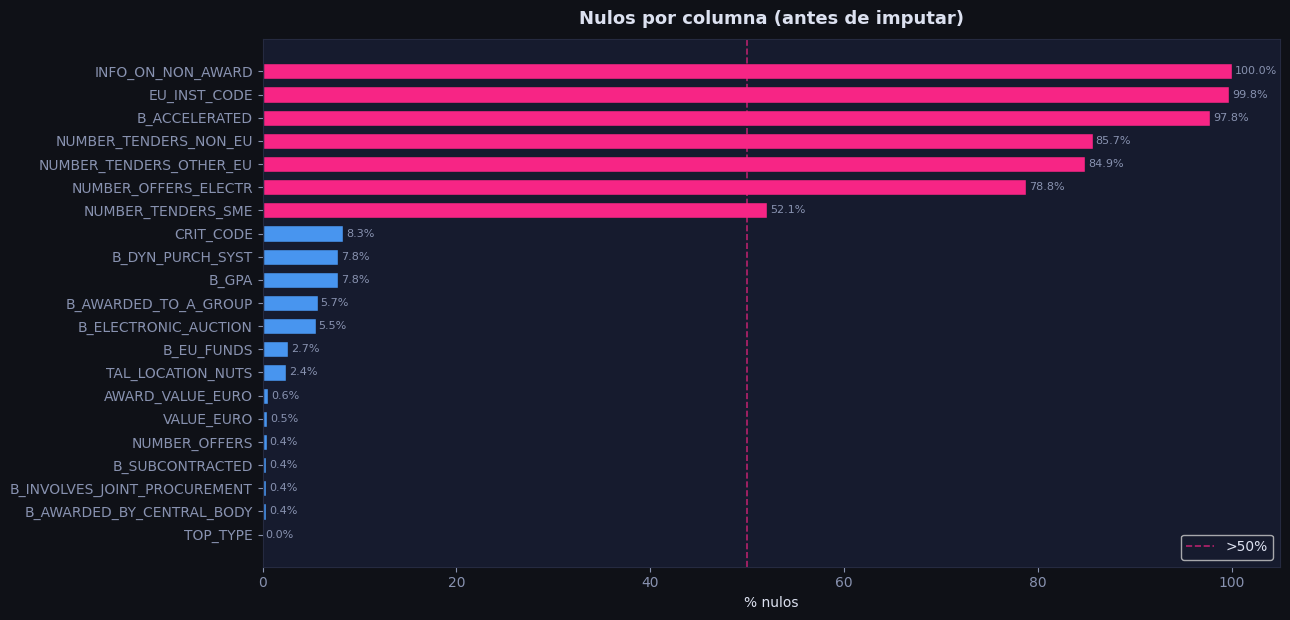

In [9]:
features = [c for c in df.columns if c != 'TARGET']
num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df[features].select_dtypes(include=['object']).columns.tolist()

print(f'Features numericas  : {len(num_cols)}')
print(f'Features categoricas: {len(cat_cols)}')

null_pct = (df[features].isna().mean() * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

if len(null_pct):
    fig, ax = plt.subplots(figsize=(13, max(3, len(null_pct) * 0.3)))
    colors = [ACC2 if v > 50 else ACC if v > 20 else '#4895ef' for v in null_pct]
    ax.barh(null_pct.index[::-1], null_pct.values[::-1], color=colors[::-1], edgecolor=AX, height=0.7)
    ax.axvline(50, color=ACC2, lw=1.2, ls='--', alpha=0.7, label='>50%')
    ax.set_xlabel('% nulos'); ax.set_title('Nulos por columna (antes de imputar)')
    ax.legend()
    for i, v in enumerate(null_pct.values[::-1]):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8, color=MUTED)
    plt.tight_layout(); plt.show()

In [10]:
# Columnas con >80% nulos → eliminar
HIGH_NULL_THRESH = 80.0
high_null_cols = null_pct[null_pct > HIGH_NULL_THRESH].index.tolist()
if high_null_cols:
    print(f'Drop por >80% nulos: {high_null_cols}')
    df.drop(columns=high_null_cols, inplace=True)
    features   = [c for c in features if c not in high_null_cols]
    num_cols   = [c for c in num_cols  if c not in high_null_cols]
    cat_cols   = [c for c in cat_cols  if c not in high_null_cols]

# Numericas → mediana
medians = df[num_cols].median()
df[num_cols] = df[num_cols].fillna(medians)
print(f'✅ Numericas imputadas con mediana: {len(num_cols)} columnas')

# Categoricas → 'UNKNOWN'
df[cat_cols] = df[cat_cols].fillna('UNKNOWN')
print(f'✅ Categoricas imputadas con UNKNOWN: {len(cat_cols)} columnas')

print(f'\nNulos restantes: {df.isna().sum().sum()}')

Drop por >80% nulos: ['INFO_ON_NON_AWARD', 'EU_INST_CODE', 'B_ACCELERATED', 'NUMBER_TENDERS_NON_EU', 'NUMBER_TENDERS_OTHER_EU']
✅ Numericas imputadas con mediana: 11 columnas
✅ Categoricas imputadas con UNKNOWN: 20 columnas

Nulos restantes: 0


## 7. Decision 11 — Encoding de categoricas

In [11]:
# Binarias Y/N → 1/0/-1
yn_cols = [c for c in cat_cols
           if set(df[c].dropna().unique()).issubset({'Y', 'N', 'UNKNOWN'})]
for c in yn_cols:
    df[c] = df[c].map({'Y': 1, 'N': 0, 'UNKNOWN': -1}).fillna(-1).astype(int)
print(f'✅ Binarias Y/N convertidas: {yn_cols}')

# Resto → Label Encoding
remaining_cat = [c for c in cat_cols if c not in yn_cols]
le_dict = {}
for c in remaining_cat:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    le_dict[c] = le
print(f'✅ Label Encoding aplicado: {remaining_cat}')

✅ Binarias Y/N convertidas: ['B_MULTIPLE_CAE', 'B_MULTIPLE_COUNTRY', 'B_ON_BEHALF', 'B_INVOLVES_JOINT_PROCUREMENT', 'B_AWARDED_BY_CENTRAL_BODY', 'B_FRA_AGREEMENT', 'B_FRA_CONTRACT', 'B_DYN_PURCH_SYST', 'B_GPA', 'B_EU_FUNDS', 'B_ELECTRONIC_AUCTION', 'INFO_UNPUBLISHED', 'B_AWARDED_TO_A_GROUP', 'B_SUBCONTRACTED']
✅ Label Encoding aplicado: ['CAE_TYPE', 'MAIN_ACTIVITY', 'TYPE_OF_CONTRACT', 'TAL_LOCATION_NUTS', 'TOP_TYPE', 'CRIT_CODE']


## 8. Dataset final — resumen y guardado

In [12]:
features_final = [c for c in df.columns if c != 'TARGET']
X = df[features_final]
y = df['TARGET']

print('=' * 55)
print('   ✅ DATASET LISTO PARA CLASIFICACION')
print('=' * 55)
print(f'  Filas          : {len(df):,}')
print(f'  Features       : {len(features_final)}')
print(f'  Target         : B_CONTRACTOR_SME  (PYME=1 / No-PYME=0)')
pyme_pct = y.mean() * 100
print(f'  Balance        : {pyme_pct:.1f}% PYME  /  {100 - pyme_pct:.1f}% No-PYME')
print(f'  Nulos restantes: {df.isna().sum().sum()}')
print('=' * 55)
print('\nFeatures finales:')
for i, col in enumerate(features_final, 1):
    dtype = str(df[col].dtype)
    risk  = '  ⚠️ leakage' if col in LEAKAGE_RISK else ''
    print(f'  {i:2}. {col:<35} [{dtype}]{risk}')

   ✅ DATASET LISTO PARA CLASIFICACION
  Filas          : 232,665
  Features       : 31
  Target         : B_CONTRACTOR_SME  (PYME=1 / No-PYME=0)
  Balance        : 45.4% PYME  /  54.6% No-PYME
  Nulos restantes: 0

Features finales:
   1. YEAR                                [int64]
   2. ID_TYPE                             [int64]
   3. CORRECTIONS                         [int64]
   4. B_MULTIPLE_CAE                      [int64]
   5. B_MULTIPLE_COUNTRY                  [int64]
   6. CAE_TYPE                            [int64]
   7. MAIN_ACTIVITY                       [int64]
   8. B_ON_BEHALF                         [int64]
   9. B_INVOLVES_JOINT_PROCUREMENT        [int64]
  10. B_AWARDED_BY_CENTRAL_BODY           [int64]
  11. TYPE_OF_CONTRACT                    [int64]
  12. TAL_LOCATION_NUTS                   [int64]
  13. B_FRA_AGREEMENT                     [int64]
  14. B_FRA_CONTRACT                      [int64]
  15. B_DYN_PURCH_SYST                    [int64]
  16. CPV        

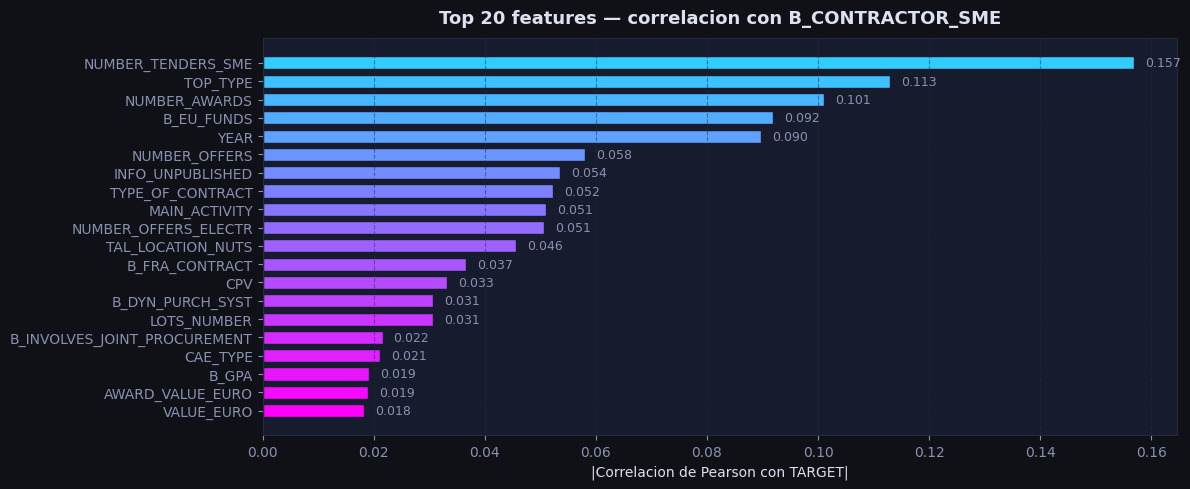

In [13]:
# Correlacion con target
corr_target = X.corrwith(y).abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
grad = plt.cm.cool(np.linspace(0.2, 1, len(corr_target)))
bars = ax.barh(corr_target.index[::-1], corr_target.values[::-1],
               color=grad[::-1], edgecolor=AX, height=0.72)
ax.set_xlabel('|Correlacion de Pearson con TARGET|')
ax.set_title('Top 20 features — correlacion con B_CONTRACTOR_SME')
ax.grid(True, axis='x')
for bar, val in zip(bars, corr_target.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color=MUTED)
plt.tight_layout(); plt.show()

In [14]:
OUT_PATH = 'dataset_preprocessed_ES_SME.csv'
df.to_csv(OUT_PATH, index=False)
print(f'Guardado en {OUT_PATH}  ({df.shape[0]:,} filas x {df.shape[1]} cols)')

Guardado en dataset_preprocessed_ES_SME.csv  (232,665 filas x 32 cols)
